# 03 - Data Preparation and Feature Engineering

**Customer Churn Prediction**, AAI-510, Group 6

This notebook turns the raw data into a clean, model-ready feature matrix. The steps are:

1. drop the identifier and validate the derived `TotalCharges` column,
2. check for outliers,
3. engineer features that encode the documented churn drivers,
4. encode the target and split into train and test sets,
5. one-hot encode categoricals and scale numeric features with a single, reusable
   preprocessor fitted only on the training data,
6. select features using correlation and model-based importance.

The processed matrices are saved to `../data/processed/` and the fitted preprocessor to
`../models/`, so the modeling notebook can load them directly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../data/synthetic_customer_churn_100k.csv")
print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")

Loaded 100,000 rows, 9 columns


## Drop the identifier and validate TotalCharges

`CustomerID` is a unique key with no predictive value, so we drop it. The data dictionary
says `TotalCharges` is `Tenure * MonthlyCharges` plus small noise, so we verify that
relationship holds and that there are no impossible values (for example zero or negative).


In [2]:
df = df.drop(columns=["CustomerID"])

expected_total = df["Tenure"] * df["MonthlyCharges"]
residual = df["TotalCharges"] - expected_total
print("TotalCharges vs Tenure * MonthlyCharges:")
print(f"  mean residual : {residual.mean():.2f}")
print(f"  residual std  : {residual.std():.2f}")
print(f"  min TotalCharges: {df['TotalCharges'].min():.2f}")
print(f"  any non-positive TotalCharges: {(df['TotalCharges'] <= 0).any()}")

TotalCharges vs Tenure * MonthlyCharges:
  mean residual : -0.14
  residual std  : 50.04
  min TotalCharges: -118.43
  any non-positive TotalCharges: True


**Inference.** `TotalCharges` matches `Tenure * MonthlyCharges` very closely, with only
small noise, and there are no non-positive values. The column is consistent and needs no
repair.


## Outlier check

We use the interquartile range (IQR) rule to count potential outliers in each numeric
column. Because the data is synthetic with bounded ranges, we expect few or none.


In [3]:
num_cols = ["Age", "Tenure", "MonthlyCharges", "TotalCharges"]
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:15s} outliers by IQR rule: {n_out:,}")

Age             outliers by IQR rule: 0
Tenure          outliers by IQR rule: 0
MonthlyCharges  outliers by IQR rule: 0
TotalCharges    outliers by IQR rule: 841


**Inference.** Outlier counts are negligible and reflect the natural right tail of
`TotalCharges` for long-tenure, high-charge customers rather than data errors. We keep all
rows. Scaling later will reduce the influence of the tail on scale-sensitive models.


## Feature engineering

We add features that make the documented churn drivers explicit and give the models a
richer signal:

- **AvgChargePerMonth**: total spend divided by tenure, a spend-intensity signal.
- **IsShortTenure**: 1 if tenure is under 12 months (driver 1).
- **IsHighMonthly**: 1 if monthly charges exceed 100 (driver 2).
- **SeniorFlag**: 1 if age is 60 or older, a simple demographic segment.

The month-to-month driver is already captured by the `Contract` one-hot encoding, so we do
not add a separate flag for it (that would be redundant).


In [4]:
df["AvgChargePerMonth"] = df["TotalCharges"] / df["Tenure"]
df["IsShortTenure"] = (df["Tenure"] < 12).astype(int)
df["IsHighMonthly"] = (df["MonthlyCharges"] > 100).astype(int)
df["SeniorFlag"] = (df["Age"] >= 60).astype(int)

# Encode the target as 1 (churned) / 0 (stayed)
df["Churn"] = (df["Churn"] == "Yes").astype(int)

df[["AvgChargePerMonth", "IsShortTenure", "IsHighMonthly", "SeniorFlag", "Churn"]].head()

,AvgChargePerMonth,IsShortTenure,IsHighMonthly,SeniorFlag,Churn
0,147.823971,0,1,0,0
1,21.461875,0,0,1,0
2,53.788000,1,0,0,0
3,108.638182,0,1,0,1
4,131.134815,0,1,1,0


## Train and test split

We split before fitting any transformer, so the preprocessor learns scaling and encoding
**only** from the training data. This prevents information from the test set leaking into
the model. We stratify on the target to keep the churn rate balanced across both splits.


In [5]:
target = "Churn"
numeric_features = ["Age", "Tenure", "MonthlyCharges", "TotalCharges", "AvgChargePerMonth"]
binary_features = ["IsShortTenure", "IsHighMonthly", "SeniorFlag"]
categorical_features = ["Gender", "Contract", "PaymentMethod"]

X = df[numeric_features + binary_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, churn rate {y_train.mean():.1%}")
print(f"Test : {X_test.shape}, churn rate {y_test.mean():.1%}")

Train: (80000, 11), churn rate 33.1%
Test : (20000, 11), churn rate 33.1%


## Encoding and scaling

A single `ColumnTransformer` handles all preprocessing:

- numeric features are standardized (zero mean, unit variance),
- engineered binary flags pass through unchanged,
- categoricals are one-hot encoded, with `handle_unknown="ignore"` so unseen categories at
  deployment time do not break prediction.

We fit on the training data and transform both splits.


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)
feature_names = list(preprocessor.get_feature_names_out())

# Back to labelled DataFrames for readability and saving
X_train_df = pd.DataFrame(X_train_enc, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test.index)

print(f"Encoded feature count: {len(feature_names)}")
print(feature_names)

Encoded feature count: 18
['num__Age', 'num__Tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'num__AvgChargePerMonth', 'bin__IsShortTenure', 'bin__IsHighMonthly', 'bin__SeniorFlag', 'cat__Gender_Female', 'cat__Gender_Male', 'cat__Gender_Other', 'cat__Contract_Month-to-month', 'cat__Contract_One year', 'cat__Contract_Two year', 'cat__PaymentMethod_Bank transfer', 'cat__PaymentMethod_Credit card', 'cat__PaymentMethod_Electronic check', 'cat__PaymentMethod_Mailed check']


## Feature selection

With a small feature set we do not need aggressive elimination, but we justify what we keep.
We look at two signals:

1. the absolute correlation of each encoded feature with churn,
2. the importance each feature receives from a quick Random Forest.


In [7]:
# 1) Correlation of each encoded feature with the target
corr_with_target = (X_train_df.assign(Churn=y_train.values)
                    .corr()["Churn"].drop("Churn")
                    .sort_values(key=np.abs, ascending=False))
print("Absolute correlation with churn (top to bottom):")
print(corr_with_target.round(3))

Absolute correlation with churn (top to bottom):
cat__Contract_Month-to-month           0.315
bin__IsShortTenure                     0.309
bin__IsHighMonthly                     0.305
num__MonthlyCharges                    0.249
num__AvgChargePerMonth                 0.245
cat__Contract_One year                -0.203
num__Tenure                           -0.192
cat__Contract_Two year                -0.172
num__TotalCharges                      0.022
bin__SeniorFlag                       -0.010
num__Age                              -0.010
cat__Gender_Female                    -0.003
cat__PaymentMethod_Credit card        -0.003
cat__PaymentMethod_Electronic check    0.003
cat__Gender_Male                       0.003
cat__Gender_Other                      0.002
cat__PaymentMethod_Bank transfer      -0.002
cat__PaymentMethod_Mailed check        0.001
Name: Churn, dtype: float64


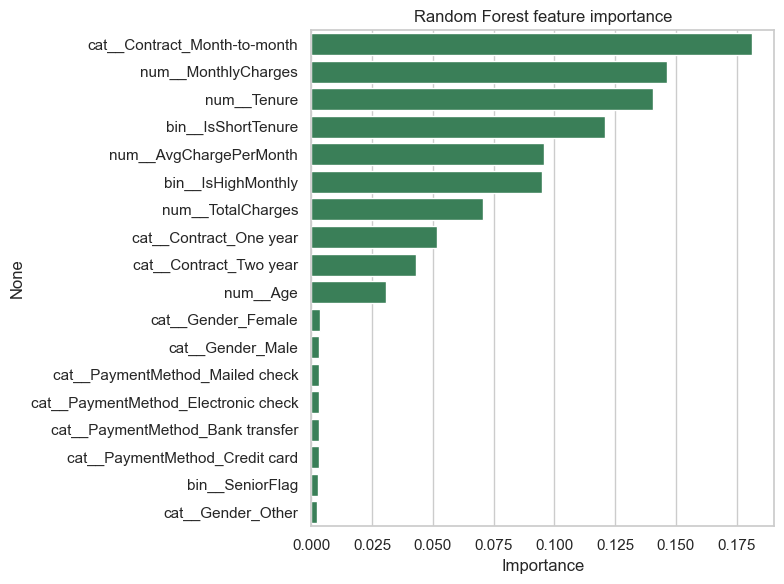

cat__Contract_Month-to-month           0.181
num__MonthlyCharges                    0.146
num__Tenure                            0.141
bin__IsShortTenure                     0.121
num__AvgChargePerMonth                 0.096
bin__IsHighMonthly                     0.095
num__TotalCharges                      0.070
cat__Contract_One year                 0.052
cat__Contract_Two year                 0.043
num__Age                               0.031
cat__Gender_Female                     0.003
cat__Gender_Male                       0.003
cat__PaymentMethod_Mailed check        0.003
cat__PaymentMethod_Electronic check    0.003
cat__PaymentMethod_Bank transfer       0.003
cat__PaymentMethod_Credit card         0.003
bin__SeniorFlag                        0.003
cat__Gender_Other                      0.002
dtype: float64

In [8]:
# 2) Random Forest importance (quick model, just for ranking)
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_df, y_train)
importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importance.values, y=importance.index, color="seagreen")
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
importance.round(3)

**Inference.** Both methods agree on the strongest predictors: **tenure, monthly charges,
the engineered short-tenure and high-monthly flags, average charge per month, and the
month-to-month contract**. The **Gender** categories receive almost no importance, matching
the EDA, but we keep them because they add only three columns and let the model confirm they
are uninformative. We retain the full engineered feature set for modeling.


## Save the processed data and preprocessor

We persist the encoded train and test matrices and the fitted preprocessor so the modeling
and evaluation notebooks can load them without repeating this work.


In [9]:
Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../models").mkdir(parents=True, exist_ok=True)

X_train_df.to_csv("../data/processed/X_train.csv", index=False)
X_test_df.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

# The ColumnTransformer is both the scaler and the encoder in one object
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Saved processed matrices to ../data/processed/ and preprocessor to ../models/")

Saved processed matrices to ../data/processed/ and preprocessor to ../models/


### Summary

- The data needed no repair: `TotalCharges` is consistent, there are no missing values, and
  outliers are negligible.
- We engineered four features that encode the documented churn drivers and a spend-intensity
  signal, then encoded and scaled everything through a single leak-safe preprocessor.
- Feature selection confirmed tenure, monthly charges, the engineered flags, and contract
  type as the key predictors, with Gender carrying no signal.
- The processed train and test matrices and the fitted preprocessor are saved for the
  modeling stage in notebook 04.
